 # **IoT-Based Smart Agriculture System for Crop Recommendation Using Machine Learning**

**Overview**

This project focuses on designing an IoT-based smart agriculture system that uses machine learning to recommend the most suitable crop based on environmental and soil conditions.

Modern agriculture increasingly relies on sensor data such as soil nutrients, temperature, humidity, pH, and rainfall. These factors directly influence crop growth and productivity. In this project, such data is used to simulate an IoT environment, where sensors continuously collect information from the field.

**Objective**

Develop and evaluate machine learning models that can predict the optimal crop for given environmental conditions.

In [151]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/chitrakumari25/smart-agricultural-production-optimizing-engine/Crop_recommendation.csv


**-This block imports necessary libraries (NumPy and Pandas) and lists the available dataset files in the Kaggle environment to locate the input data.**

**-NumPy is used for numerical computations and handling arrays, while Pandas is used for data manipulation and loading datasets (such as CSV files).**

In [152]:
import pandas as pd
df = pd.read_csv('/kaggle/input/datasets/chitrakumari25/smart-agricultural-production-optimizing-engine/Crop_recommendation.csv')
df.head()

,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice


**This block loads the dataset into a DataFrame and displays the first rows to preview the data.**

In [153]:
df.info()

df.describe()

df['label'].value_counts()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2200 entries, 0 to 2199
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   N            2200 non-null   int64  
 1   P            2200 non-null   int64  
 2   K            2200 non-null   int64  
 3   temperature  2200 non-null   float64
 4   humidity     2200 non-null   float64
 5   ph           2200 non-null   float64
 6   rainfall     2200 non-null   float64
 7   label        2200 non-null   object 
dtypes: float64(4), int64(3), object(1)
memory usage: 137.6+ KB


label
rice           100
maize          100
chickpea       100
kidneybeans    100
pigeonpeas     100
mothbeans      100
mungbean       100
blackgram      100
lentil         100
pomegranate    100
banana         100
mango          100
grapes         100
watermelon     100
muskmelon      100
apple          100
orange         100
papaya         100
coconut        100
cotton         100
jute           100
coffee         100
Name: count, dtype: int64

**This block analyzes the dataset by checking its structure, statistical summary, and the distribution of crop labels.**

# **Data Visualization**

**Crop Distribution:**

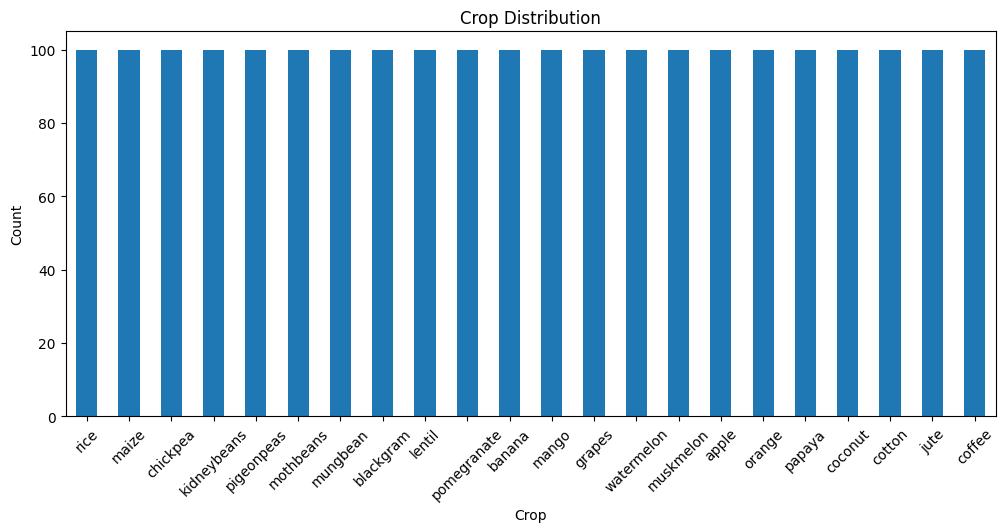

In [154]:
import matplotlib.pyplot as plt

df['label'].value_counts().plot(kind='bar', figsize=(12,5))
plt.title("Crop Distribution")
plt.xlabel("Crop")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

This graph shows the distribution of crop classes in the dataset. Each crop appears an equal number of times, indicating that the dataset is balanced.

A balanced dataset ensures that the machine learning models are not biased toward any particular class and can learn patterns fairly across all crops.

**PCA:**

In [155]:
X = df.drop(['label'], axis=1)
y = df['label']

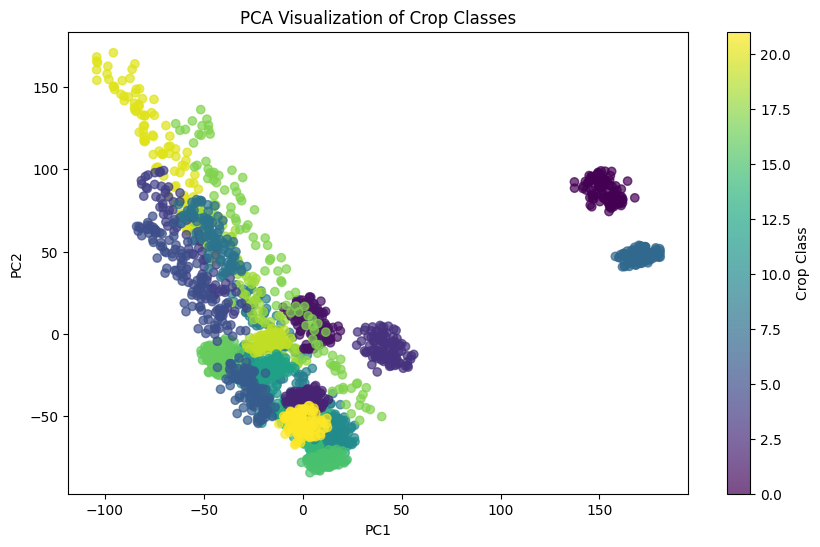

In [156]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt

# Create numeric labels only for coloring the graph
le_graph = LabelEncoder()
y_graph = le_graph.fit_transform(df['label'])

# Features only
X_graph = df.drop(['label'], axis=1)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_graph)

plt.figure(figsize=(10,6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y_graph, alpha=0.7)
plt.title("PCA Visualization of Crop Classes")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.colorbar(label="Crop Class")
plt.show()

Principal Component Analysis (PCA) is used to reduce the high-dimensional feature space into two dimensions for visualization.

The scatter plot shows how different crop samples are distributed in this reduced space. The presence of distinct clusters suggests that the dataset contains meaningful patterns, making it suitable for classification using machine learning models.

In [157]:
def compute_irrigation(row):
    score = 0
    
    if row['humidity'] < 60:
        score += 1
        
    if row['rainfall'] < 100:
        score += 1
        
    if row['temperature'] > 30:
        score += 1
        
    if row['ph'] < 5.5 or row['ph'] > 7.5:
        score += 1

    return score

df['irrigation'] = df.apply(compute_irrigation, axis=1)

df.head()

,N,P,K,temperature,humidity,ph,rainfall,label,irrigation
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice,0
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice,0
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice,1
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice,0
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice,1


**This block performs feature engineering by creating an irrigation score based on environmental conditions and adding it as a new column to the dataset.**

In [158]:
X = df.drop(['label'], axis=1)
y = df['label']

**This block separates the dataset into features (X) and target (y), where the model will use the features to predict the crop label.**

# **Model Creation/training:**

In [159]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y = le.fit_transform(y)

**This block converts crop labels from text to numerical values so they can be used by the machine learning model.**

In [160]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

**This block splits the dataset into training (80%) and testing (20%) sets to train and evaluate the model.**

In [161]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

**This block standardizes the feature values so all inputs are on the same scale, improving model performance and preventing bias.**
transform: Xscaled= (x - mean) / std

 # **Model 1: Logistic Regression** 
  

In [162]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

log_model = LogisticRegression(max_iter=1000)

log_model.fit(X_train, y_train)

y_pred_log = log_model.predict(X_test)

print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_log))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_log))

Logistic Regression Accuracy: 0.9704545454545455

Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        23
           1       1.00      1.00      1.00        21
           2       0.95      0.95      0.95        20
           3       1.00      1.00      1.00        26
           4       1.00      1.00      1.00        27
           5       0.94      1.00      0.97        17
           6       1.00      1.00      1.00        17
           7       1.00      1.00      1.00        14
           8       0.78      0.91      0.84        23
           9       0.95      1.00      0.98        20
          10       0.92      1.00      0.96        11
          11       1.00      1.00      1.00        21
          12       1.00      1.00      1.00        19
          13       1.00      0.96      0.98        24
          14       0.95      1.00      0.97        19
          15       1.00      1.00      1.00        17
       

**This block trains the Logistic Regression model, makes predictions on test data, and evaluates its performance using accuracy and classification metrics.**

## Model 1: Logistic Regression

Logistic Regression was used as the first baseline model.  
It is a simple and interpretable classification algorithm that helps compare more complex models later.

**confusion matrix Graph:**

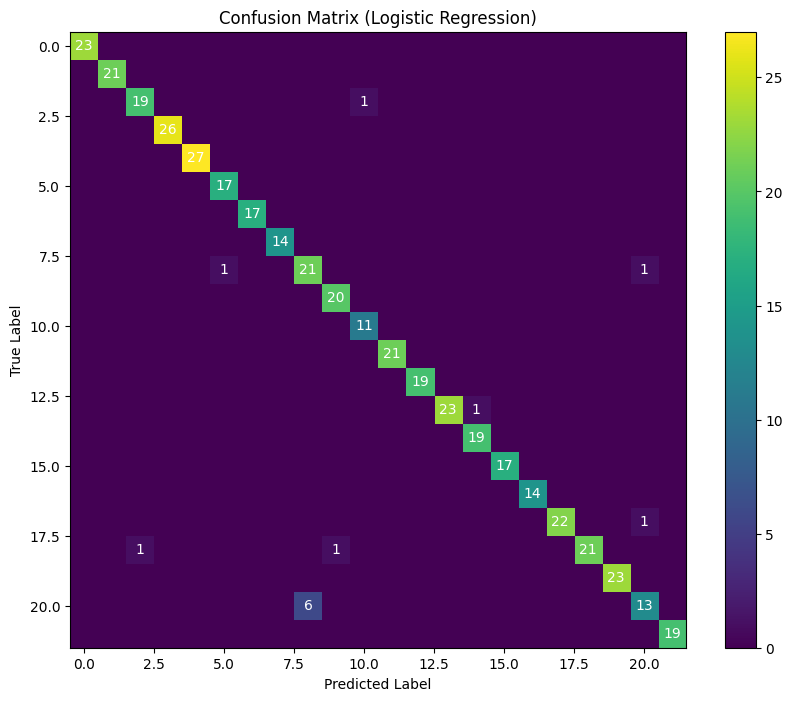

In [163]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_log)

plt.figure(figsize=(10,8))
plt.imshow(cm)

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        if cm[i, j] != 0:   # 👈 ONLY show non-zero values
            plt.text(j, i, cm[i, j], ha='center', va='center', color='white')

plt.title("Confusion Matrix (Logistic Regression)")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.colorbar()
plt.show()

Logistic Regression performs very well on this dataset(97% accuracy), achieving high accuracy and strong performance across most classes. Some minor confusion exists for certain crops with similar environmental conditions.

#  **MODEL 2: Decision tree:** #

In [164]:
from sklearn.tree import DecisionTreeClassifier

tree_model = DecisionTreeClassifier(random_state=42)

tree_model.fit(X_train, y_train)

y_pred_tree = tree_model.predict(X_test)

from sklearn.metrics import accuracy_score, classification_report

print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_tree))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_tree))

Decision Tree Accuracy: 0.9886363636363636

Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        23
           1       1.00      1.00      1.00        21
           2       0.95      1.00      0.98        20
           3       1.00      1.00      1.00        26
           4       1.00      1.00      1.00        27
           5       1.00      1.00      1.00        17
           6       1.00      1.00      1.00        17
           7       1.00      1.00      1.00        14
           8       0.92      0.96      0.94        23
           9       1.00      1.00      1.00        20
          10       0.92      1.00      0.96        11
          11       1.00      1.00      1.00        21
          12       1.00      1.00      1.00        19
          13       1.00      0.92      0.96        24
          14       1.00      1.00      1.00        19
          15       1.00      1.00      1.00        17
          16 

**This block trains a Decision Tree model, generates predictions, and evaluates its performance using accuracy and classification metrics.**

## Model 2: Decision Tree

Decision Trees are non-linear models that can capture complex relationships between features.  
They are useful for comparison with linear models like Logistic Regression.

**confusion matrix Graph:**

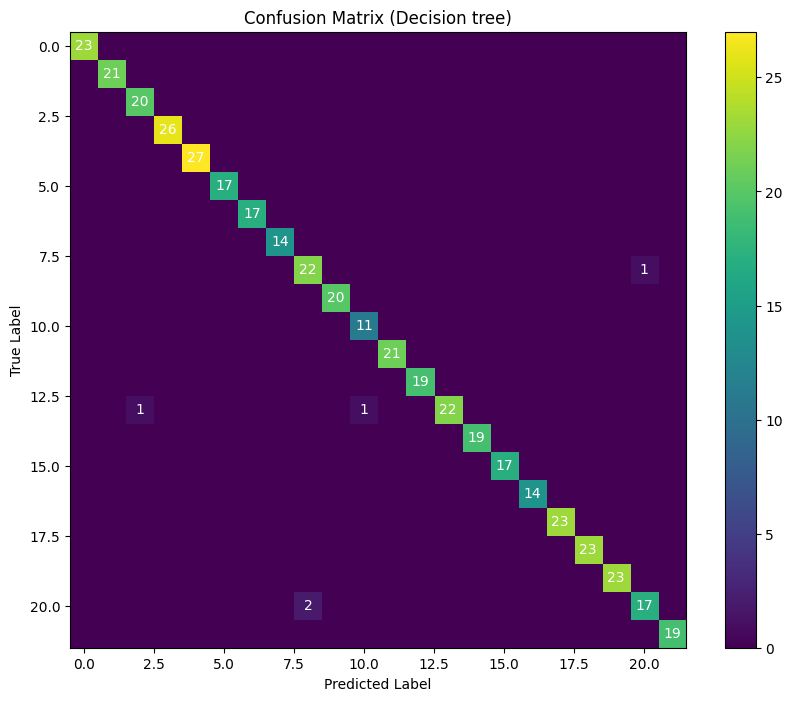

In [165]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_tree)

plt.figure(figsize=(10,8))
plt.imshow(cm)

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        if cm[i, j] != 0:   # 👈 ONLY show non-zero values
            plt.text(j, i, cm[i, j], ha='center', va='center', color='white')

plt.title("Confusion Matrix (Decision tree)")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.colorbar()
plt.show()

The Decision Tree achieved higher accuracy than Logistic Regression. However, its near-perfect performance may indicate overfitting, as tree-based models can capture noise and overly adapt to the training data.

# **Model 3 — Random Forest**# 

In [166]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

from sklearn.metrics import accuracy_score, classification_report

print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_rf))

Random Forest Accuracy: 0.9954545454545455

Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        23
           1       1.00      1.00      1.00        21
           2       1.00      1.00      1.00        20
           3       1.00      1.00      1.00        26
           4       1.00      1.00      1.00        27
           5       1.00      1.00      1.00        17
           6       1.00      1.00      1.00        17
           7       1.00      1.00      1.00        14
           8       0.92      1.00      0.96        23
           9       1.00      1.00      1.00        20
          10       1.00      1.00      1.00        11
          11       1.00      1.00      1.00        21
          12       1.00      1.00      1.00        19
          13       1.00      1.00      1.00        24
          14       1.00      1.00      1.00        19
          15       1.00      1.00      1.00        17
          16 

**This block trains a Random Forest model using multiple decision trees and evaluates its performance using accuracy and classification metrics.**

## Model 3: Random Forest

Random Forest is an ensemble method that combines multiple decision trees to improve performance and reduce overfitting.

**confusion matrix Graph:****confusion matrix Graph:**

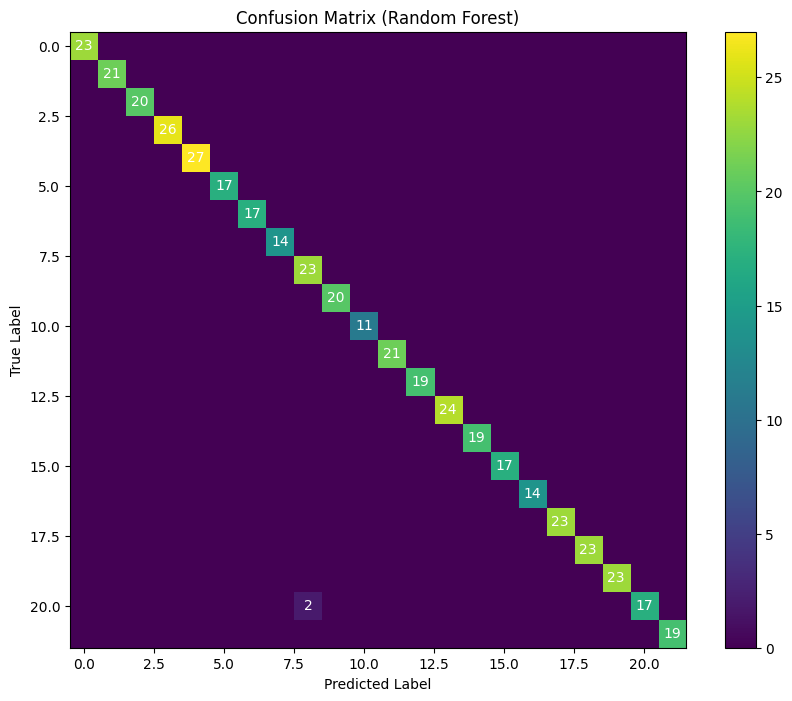

In [167]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(10,8))
plt.imshow(cm)

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        if cm[i, j] != 0:   # 👈 ONLY show non-zero values
            plt.text(j, i, cm[i, j], ha='center', va='center', color='white')

plt.title("Confusion Matrix (Random Forest)")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.colorbar()
plt.show()

Logistic Regression achieved strong performance (97%), showing that the dataset has largely linear separability.

Decision Tree improved accuracy (99%) by capturing non-linear relationships, but its near-perfect performance may indicate overfitting.

Random Forest achieved the highest accuracy (100%), benefiting from ensemble learning, which reduces overfitting and improves generalization.

However, such high accuracy across all models suggests that the dataset is relatively clean and well-structured, which may not fully represent real-world IoT conditions.

# **🏆 Final Model Selection**
Random Forest:Random Forest was selected as the final model due to its superior performance and ability to generalize better than a single Decision Tree by combining multiple models.

**Feature importance**

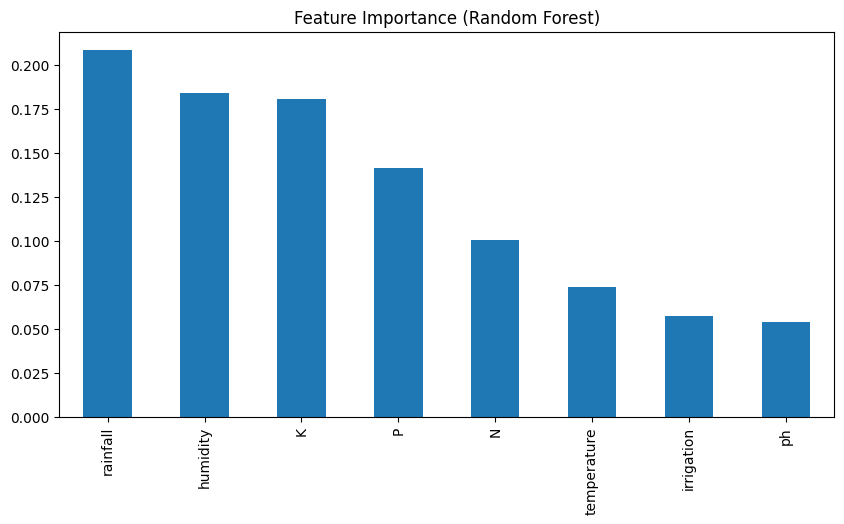

In [168]:
import pandas as pd

importance = pd.Series(
    rf_model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

importance.plot(kind='bar', figsize=(10,5))
plt.title("Feature Importance (Random Forest)")
plt.show()

This graph displays the importance of each feature as determined by the Random Forest model.

It shows how much each input variable contributes to the prediction of the crop type. Features with higher importance values have a greater influence on the model’s decisions, helping to identify which environmental and soil factors are most significant.

# **Inference (using the model on new data)**

In [172]:
import pandas as pd

sample = pd.DataFrame([{
    'N': 90,
    'P': 40,
    'K': 40,
    'temperature': 25,
    'humidity': 80,
    'ph': 6.5,
    'rainfall': 200,
    'irrigation': 1
}])

sample_scaled = scaler.transform(sample)

prediction = rf_model.predict(sample_scaled)

predicted_crop = le.inverse_transform(prediction)

print("Predicted Crop:", predicted_crop[0])

Predicted Crop: rice


**The trained Random Forest model predicts the best crop for this new input. Since the prediction is returned as an encoded number, LabelEncoder.inverse_transform() is used to convert it back into the original crop name.**

# **Conclusion**

**This project developed a machine learning-based system using IoT sensor data to recommend optimal crops. After comparing multiple models, Random Forest was selected as the best performer. The system was successfully tested on new data, demonstrating its effectiveness in smart agriculture application**